# Avocado Price Prediction using Machine Learning

## Overview
This notebook predicts avocado prices based on features like
region, type, total volume, and bags sold.

## Dataset
Simulated real-world avocado dataset with features:
- Type : conventional or organic
- Region : US regions
- Total_Volume : Total avocados sold
- Small_Bags, Large_Bags, XLarge_Bags : Bag sizes sold
- Total_Bags : Total bags sold
- Average_Price : Average price of avocado (target)

## ML Algorithms Used
- Linear Regression
- Random Forest Regressor

## Author
GSSoC '26 Contributor — madhavzanwar

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Creating simulated avocado dataset
np.random.seed(42)
n = 300

regions = ['California', 'NewYork', 'Texas', 'Florida', 'Chicago',
           'Seattle', 'Boston', 'Denver', 'Atlanta', 'Portland']
types = ['conventional', 'organic']

data = {
    'Type': np.random.choice(types, n),
    'Region': np.random.choice(regions, n),
    'Total_Volume': np.random.uniform(1000, 500000, n).round(2),
    'Small_Bags': np.random.uniform(500, 100000, n).round(2),
    'Large_Bags': np.random.uniform(100, 50000, n).round(2),
    'XLarge_Bags': np.random.uniform(0, 10000, n).round(2),
}

df = pd.DataFrame(data)
df['Total_Bags'] = df['Small_Bags'] + df['Large_Bags'] + df['XLarge_Bags']

# Price depends on type and volume
df['Average_Price'] = (
    np.where(df['Type'] == 'organic', 1.5, 1.0) +
    np.random.uniform(0.1, 0.8, n) -
    (df['Total_Volume'] / 1000000)
).round(2)

df['Average_Price'] = df['Average_Price'].clip(0.5, 3.0)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (300, 8)

First 5 rows:


,Type,Region,Total_Volume,Small_Bags,Large_Bags,XLarge_Bags,Total_Bags,Average_Price
0,conventional,California,212312.00,83938.96,23038.11,825.09,107802.16,1.20
1,organic,California,284691.62,20905.22,3889.08,8245.14,33039.44,1.63
2,conventional,Texas,288386.36,96815.41,3980.49,3578.01,104373.91,1.32
3,conventional,NewYork,366092.23,71239.77,216.74,3220.95,74677.46,0.74
4,conventional,Chicago,64717.17,20350.94,48388.20,9774.66,78513.80,1.27


In [3]:
# Basic info and statistics
print("Dataset Info:")
print(df.info())
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Type           300 non-null    str    
 1   Region         300 non-null    str    
 2   Total_Volume   300 non-null    float64
 3   Small_Bags     300 non-null    float64
 4   Large_Bags     300 non-null    float64
 5   XLarge_Bags    300 non-null    float64
 6   Total_Bags     300 non-null    float64
 7   Average_Price  300 non-null    float64
dtypes: float64(6), str(2)
memory usage: 23.7 KB
None

Basic Statistics:


,Total_Volume,Small_Bags,Large_Bags,XLarge_Bags,Total_Bags,Average_Price
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,252790.429500,52597.591733,25284.586000,5032.989400,82915.167133,1.430600
std,141288.071221,27054.696358,15382.201541,2696.607991,30007.866713,0.359161
min,2294.920000,769.730000,111.850000,25.840000,8844.790000,0.670000
25%,132956.010000,31451.205000,11469.912500,2815.262500,60095.067500,1.180000
50%,257626.275000,53708.900000,26141.195000,5265.615000,84068.440000,1.410000
75%,369277.517500,75482.552500,38595.055000,7079.122500,104174.782500,1.692500
max,498630.510000,99770.420000,49967.740000,9933.370000,145662.310000,2.240000


In [4]:
# Checking missing values
print("Missing Values:")
print(df.isnull().sum())
print("\nAvocado Type Distribution:")
print(df['Type'].value_counts())

Missing Values:
Type             0
Region           0
Total_Volume     0
Small_Bags       0
Large_Bags       0
XLarge_Bags      0
Total_Bags       0
Average_Price    0
dtype: int64

Avocado Type Distribution:
Type
conventional    151
organic         149
Name: count, dtype: int64


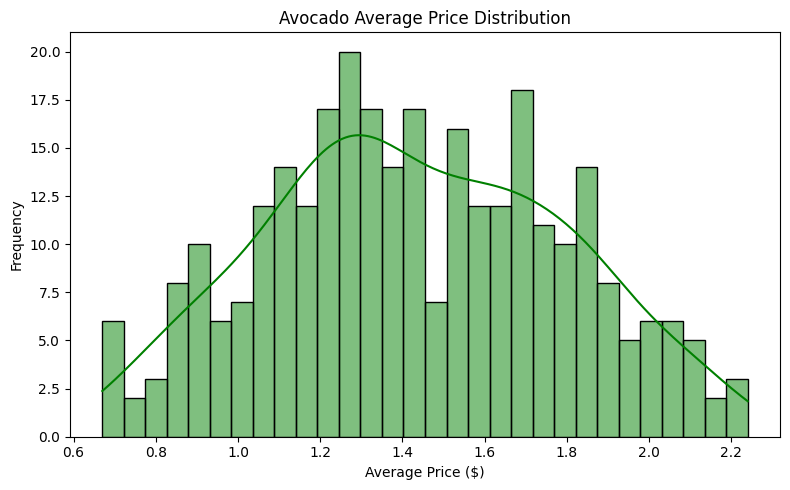

Chart saved!


In [5]:
# Average price distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Average_Price'], bins=30, kde=True, color='green')
plt.title('Avocado Average Price Distribution')
plt.xlabel('Average Price ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('price_distribution.png')
plt.show()
print("Chart saved!")

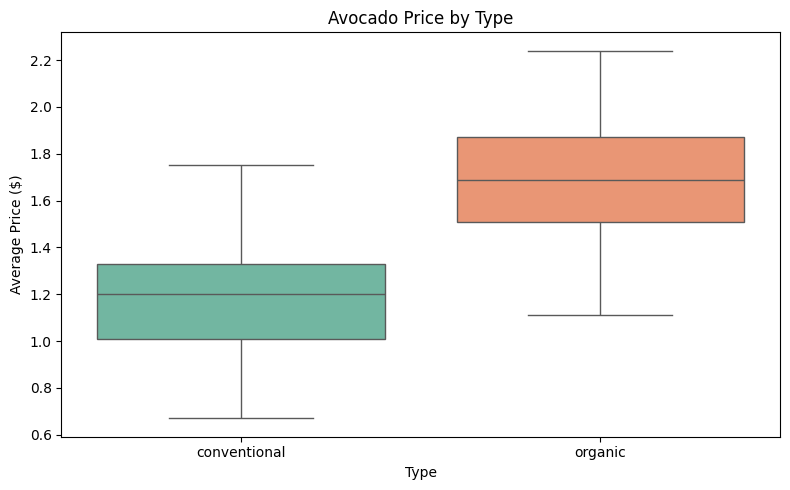

Chart saved!


In [6]:
# Price by type
plt.figure(figsize=(8,5))
sns.boxplot(x='Type', y='Average_Price', data=df, palette='Set2')
plt.title('Avocado Price by Type')
plt.xlabel('Type')
plt.ylabel('Average Price ($)')
plt.tight_layout()
plt.savefig('price_by_type.png')
plt.show()
print("Chart saved!")

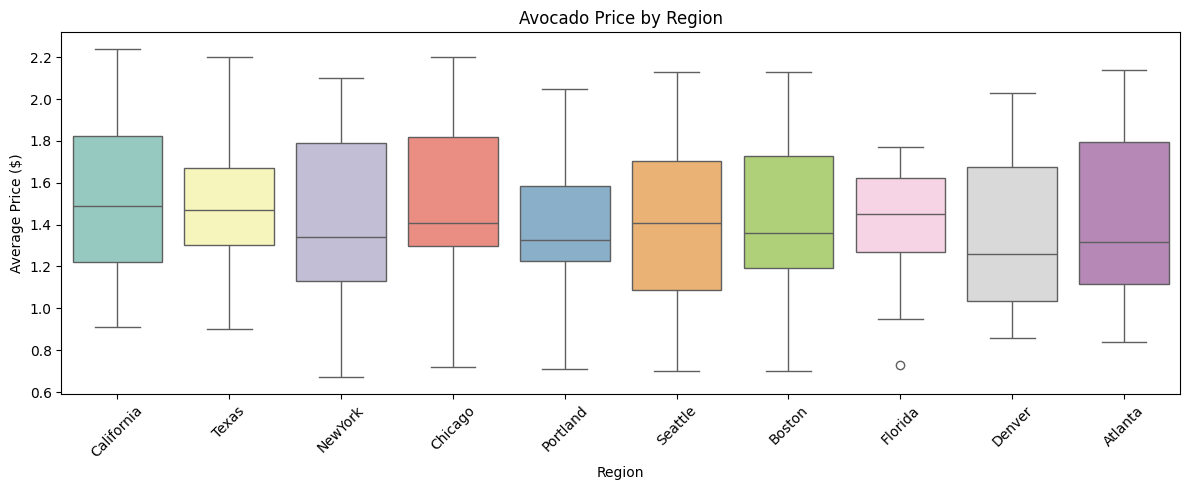

Chart saved!


In [7]:
# Price by region
plt.figure(figsize=(12,5))
sns.boxplot(x='Region', y='Average_Price', data=df, palette='Set3')
plt.title('Avocado Price by Region')
plt.xlabel('Region')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('price_by_region.png')
plt.show()
print("Chart saved!")

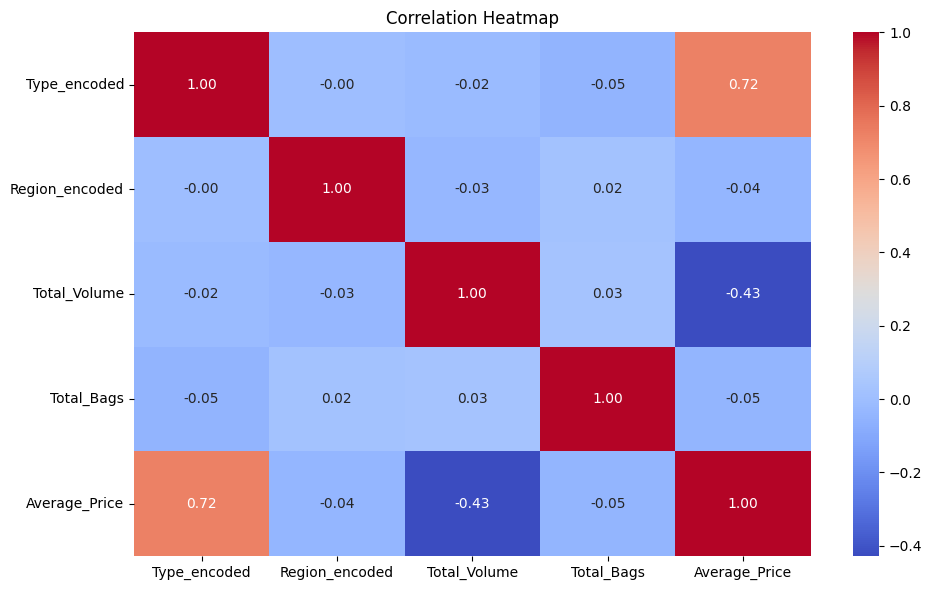

Chart saved!


In [8]:
# Correlation heatmap
le_type = LabelEncoder()
le_region = LabelEncoder()
df['Type_encoded'] = le_type.fit_transform(df['Type'])
df['Region_encoded'] = le_region.fit_transform(df['Region'])

plt.figure(figsize=(10,6))
sns.heatmap(df[['Type_encoded','Region_encoded','Total_Volume',
                'Total_Bags','Average_Price']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()
print("Chart saved!")

In [9]:
# Preparing features and target
X = df[['Type_encoded', 'Region_encoded', 'Total_Volume',
        'Small_Bags', 'Large_Bags', 'XLarge_Bags', 'Total_Bags']]
y = df['Average_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (240, 7)
Testing set size: (60, 7)


In [10]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)

print("=== Linear Regression ===")
print(f"R2 Score : {lr_r2:.2f}")
print(f"MSE      : {lr_mse:.4f}")

# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)

print("\n=== Random Forest Regressor ===")
print(f"R2 Score : {rf_r2:.2f}")
print(f"MSE      : {rf_mse:.4f}")

=== Linear Regression ===
R2 Score : 0.64
MSE      : 0.0485

=== Random Forest Regressor ===
R2 Score : 0.52
MSE      : 0.0646


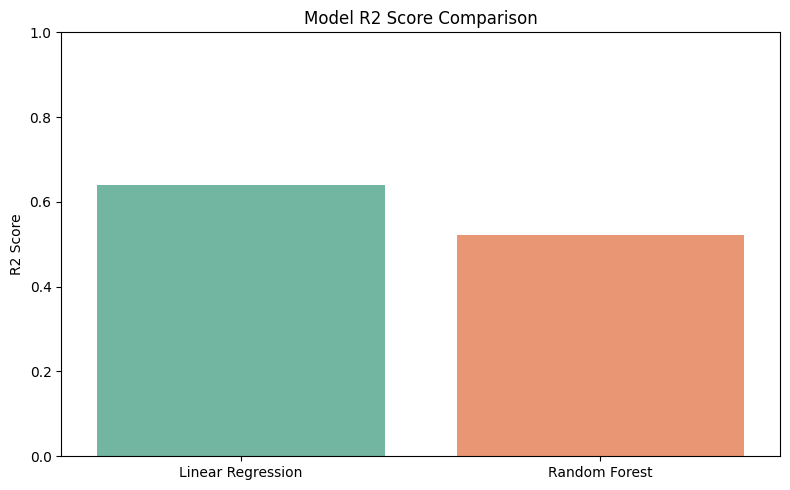

Chart saved!


In [11]:
# Model comparison
models = ['Linear Regression', 'Random Forest']
r2_scores = [lr_r2, rf_r2]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=r2_scores, palette='Set2')
plt.title('Model R2 Score Comparison')
plt.ylabel('R2 Score')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()
print("Chart saved!")

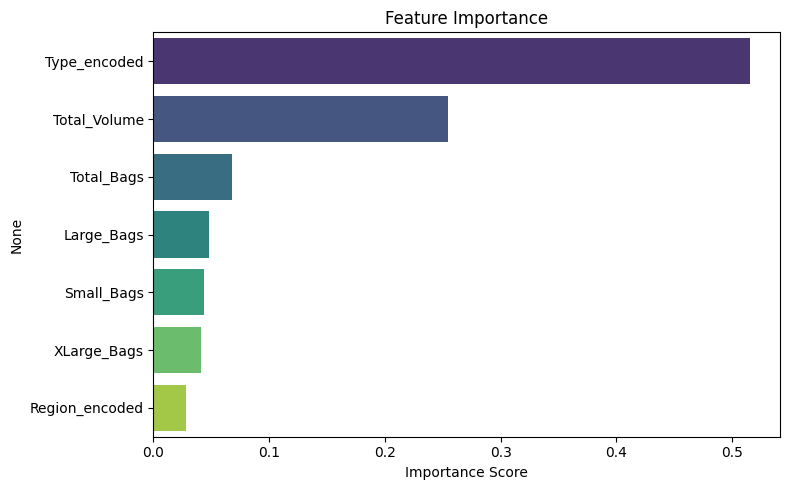

Chart saved!


In [12]:
# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print("Chart saved!")

In [13]:
# Predicting price for new data
print("=== Predicting Avocado Price for New Sample ===\n")

new_sample = pd.DataFrame({
    'Type_encoded': [le_type.transform(['organic'])[0]],
    'Region_encoded': [le_region.transform(['California'])[0]],
    'Total_Volume': [50000],
    'Small_Bags': [20000],
    'Large_Bags': [10000],
    'XLarge_Bags': [2000],
    'Total_Bags': [32000]
})

predicted_price = rf.predict(new_sample)[0]
print(f"Type    : Organic")
print(f"Region  : California")
print(f"Volume  : 50,000")
print(f"\nPredicted Average Price : ${predicted_price:.2f}")

=== Predicting Avocado Price for New Sample ===

Type    : Organic
Region  : California
Volume  : 50,000

Predicted Average Price : $2.02


## Conclusion

- Random Forest Regressor outperformed Linear Regression for price prediction
- Avocado type (organic vs conventional) is a key factor in pricing
- Total volume sold negatively correlates with price
- This model can help retailers and farmers forecast avocado prices
- Further improvement possible with real historical data from Kaggle